# 16S Analyses of the Longitudinal Acne Study
## Relative Abundance Plots

Date created: 10/15/2024

Notebook authors: Yang Chen and Britta De Pessemier

Data analysis supported by: Tyler Myers 

This notebook plots the following:

- 16S V1-V3 and V4 relative abundance plots at Family and Genus taxon level
- 16S V1-V3 and V4 Shannon lpha diversity plots at Family and Genus taxon level

In [134]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap


In [135]:
# Switch this to Genus to make the Genus level plots and Family to make the Family level plots
# taxa_level = 'Family'
taxa_level = 'Genus'

In [136]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_18062024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')

In [137]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'V1-V3': f'../Data/16S/Tables/16S_V1-V3_{taxa_level}_collapsed.biom',
    'V4': f'../Data/16S/Tables/16S_V4_{taxa_level}_collapsed.biom'
}

In [138]:
# Predefined color palette for specific families
if taxa_level == "Family":
    taxa_colors = {
        ' f__Propionibacteriaceae': '#ffa505',  # Bright orange
        ' f__Mycobacteriaceae': '#70a8dc',      # Blue
        ' f__Streptococcaceae': '#92f0f0',      # Fluorescent light blue
        ' f__Porphyromonodaceae': '#e2b46c',    # Beige
        ' f__Bacteroidaceae': '#ffe59a',        # Pastel yellow
        ' f__Neisseriaceae': '#f6475f',         # Pinkish
        ' f__Moraxellaceae': '#c5bce0',         # Pastel purplish
        ' f__Marinomonadaceae':'#f4cccd',
        ' f__Celerinatantimonadaceae': '#bcbcbc',
        ' f__Alteromonadaceae': '#daead3',
        'Others': '#ededed'                 # White
    }
elif taxa_level == "Genus":
    taxa_colors = {
        ' g__Cutibacterium': '#ffa505',  # Bright orange
        ' g__uncultured': '#70a8dc',      # Blue
        ' g__Staphylococcus': '#92f0f0',      # Fluorescent light blue
        ' g__Streptococcus': '#e2b46c',    # Beige
        ' g__Corynebacterium': '#ffe59a',        # Pastel yellow
        ' g__Lawsonella': '#f6475f',         # Pinkish
        ' g__Veillonella': '#c5bce0',         # Pastel purplish
        ' g__Micrococcus':'#f4cccd',
        ' g__Alloprevotella': '#bcbcbc',
        ' g__Lactobacillus': '#daead3',
        'Others': '#ededed'                 # White
    }

In [139]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [140]:
# Function to load BIOM table, collapse by taxa, and sort rows by row sum
def load_biom_table(biom_path):
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before returning
    df = df.drop(columns=['row_sum'])
    
    return df

In [141]:
# Function to load BIOM table and collapse by taxa
def load_biom_table(biom_path):
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    return df

In [142]:
# Function to determine the top 15 families and collapse the rest as "Others"
def collapse_top_15(df):
    top_families = df.sum(axis=1).nlargest(15).index  # Select top 15 families
    df_top = df.loc[top_families]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_families)].sum()
    return df_top

In [143]:
# Function to get or assign colors to families
def get_taxa_colors(families, global_taxa_color_map):
    for taxa in families:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

In [144]:
def plot_relative_abundance(df, metadata, group_column, output_dir, biom_key, taxa_color_map):
    # Average by group
    df_grouped = df.groupby(metadata[group_column], axis=1).mean()

    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.png')  # Save as png
    output_svg_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.svg')  # Save as svg

    # Set plot title based on biom_key
    if biom_key == 'V1-V3':
        plot_title = f'16S rRNA (V1-V3) {taxa_level} Level Relative Abundance'
    elif biom_key == 'V4':
        plot_title = f'16S rRNA (V4) {taxa_level} Level Relative Abundance'
    else:
        plot_title = f'16S rRNA (V4) {taxa_level} Level Relative Abundance'

    # Plot
    ax = df_grouped.T.plot(kind='bar', stacked=True, figsize=(10, 10),  # More rectangular
                           width=0.8,  # Bars closer together
                           color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df_grouped.index])

    plt.ylabel('Relative Abundance', fontsize=16)
    plt.xlabel(' ')
    plt.title(plot_title, fontsize=18)

    new_labels = ['Acne\nLesional', 'Acne\nNon-lesional', 'Healthy']

    # Set the new x-tick labels
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=16)

    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=12)
    plt.tight_layout()

    plt.savefig(output_png_file, format='png', dpi=600)  # Save as png
    plt.savefig(output_svg_file, format='svg')  # Save as svg
    plt.show()

    plt.close()


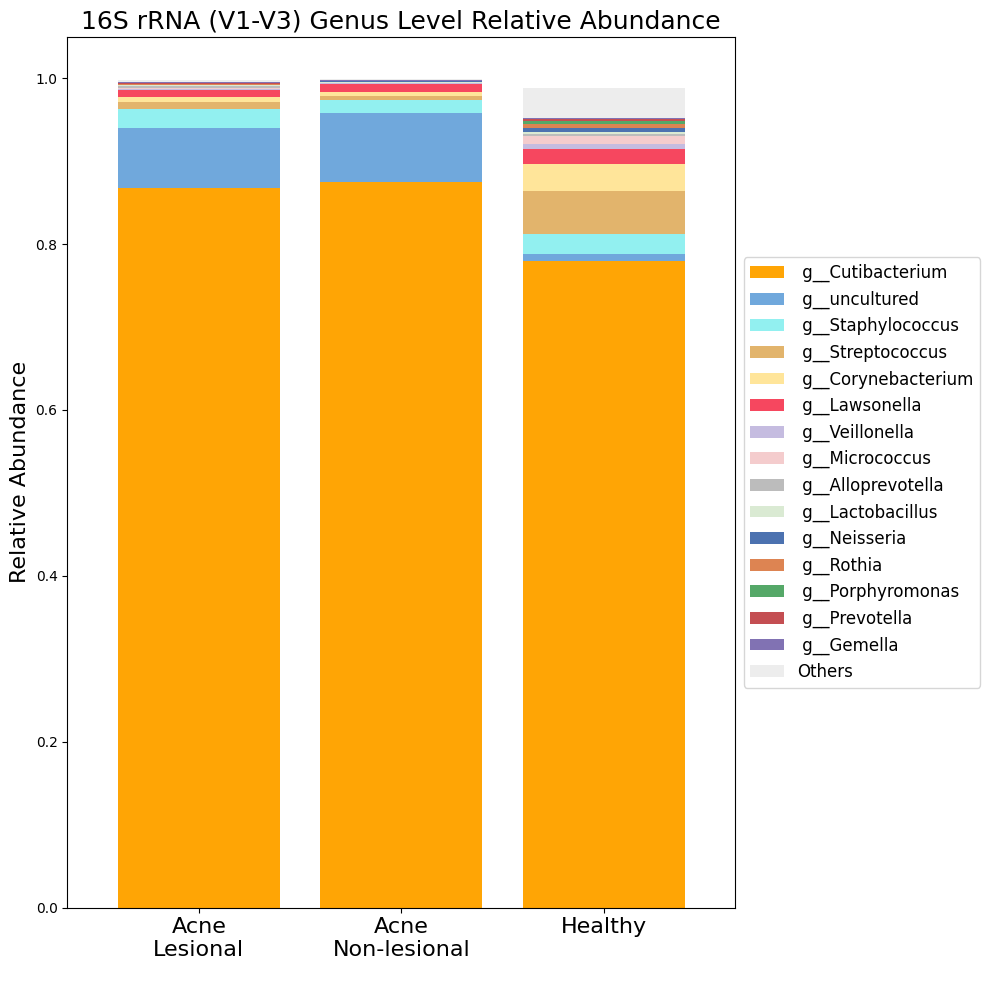

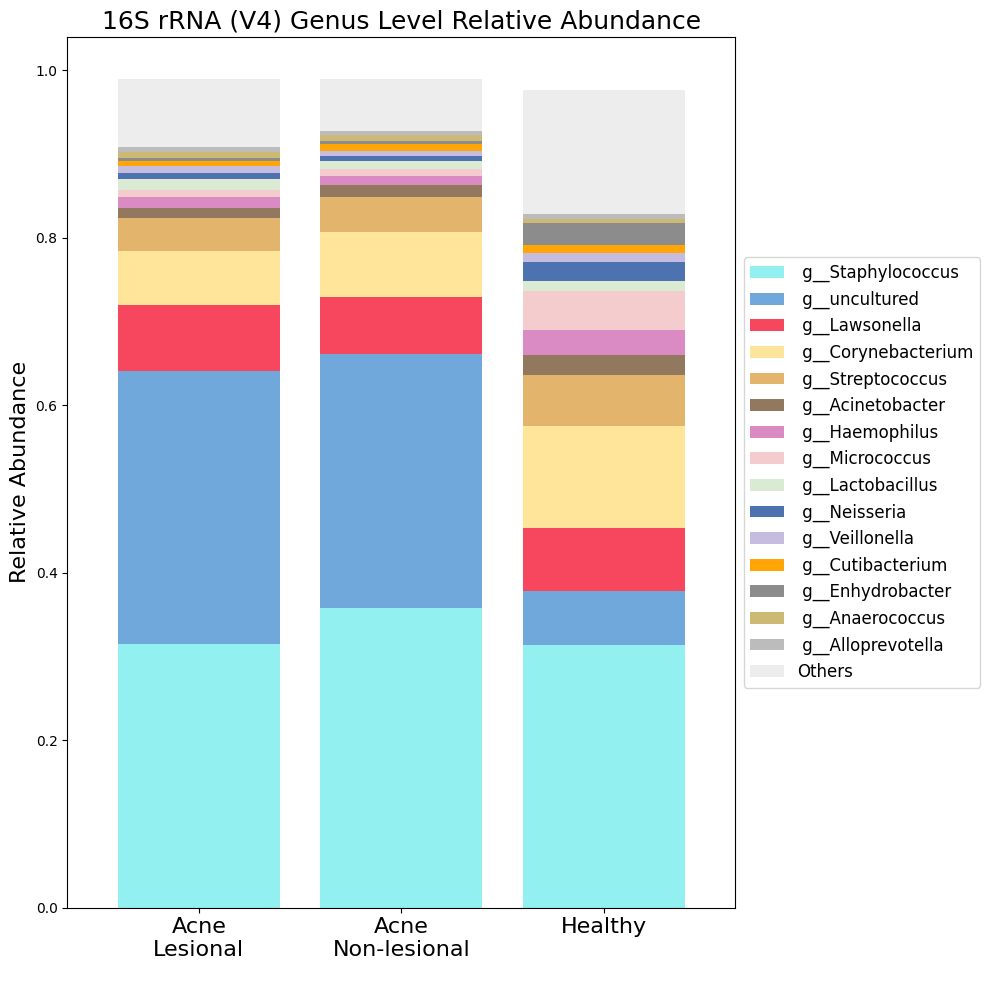

In [145]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to families across both datasets
for biom_key, biom_path in biom_paths.items():
    # Load and process the BIOM table
    df = load_biom_table(biom_path)
    df_top_15 = collapse_top_15(df)  # Now using the top 15 function
    
    # Define the output directory for the current biom_key
    output_dir = '../Figures/16S_Figures'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top families in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_15.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_relative_abundance(df_top_15, metadata_subset, 'group', output_dir, biom_key, global_taxa_color_map)

# 16S Analyses of the Longitudinal Acne Study
## Alpha Diversity Plots

In [146]:
# Additional Python packages for alpha diversity analyses
from skbio.diversity import alpha_diversity
from scipy.stats import mannwhitneyu

In [147]:
def calculate_alpha_diversity_and_plot(biom_path, metadata, group_col, title_suffix):
    # Load biom table
    feature_table = load_biom_table(biom_path)

    # Transpose feature_table so rows are sample IDs
    feature_table = feature_table.transpose()

    # Calculate Shannon diversity
    shannon_values = alpha_diversity('shannon', feature_table.values, ids=feature_table.index)
    
    # Merge Shannon values with metadata
    common_samples = metadata.index.intersection(feature_table.index)
    metadata = metadata.loc[common_samples].copy()
    metadata['Shannon'] = shannon_values.loc[common_samples]
    
    # Create a more rectangular plot
    plt.figure(figsize=(10, 6))

    # Set the color palette for the groups
    palette = {
        'Acne_L': '#f16c52',      # Red color for Acne Lesional
        'Acne_NL': '#5cbccb',     # Blue color for Acne Non-Lesional
        'Healthy': '#4CAF50'      # Green color for Healthy
    }
    
    # Create a more rectangular plot (e.g., 12 inches wide and 10 inches tall)
    plt.figure(figsize=(8, 12))
    
    # Plot the Shannon diversity across the groups using a boxplot with custom colors
    ax = sns.boxplot(x=group_col, y='Shannon', data=metadata, palette=palette)
    plt.title(f'16S rRNA ({title_suffix}) Shannon Alpha Diversity at {taxa_level} Level', fontsize=18)
    plt.xlabel(' ')
    plt.ylabel('Shannon Alpha Diversity', fontsize=16)
    
    # Custom labels for the x-axis
    new_labels = ['Acne\nLesional', 'Acne\nNon-lesional', 'Healthy']
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=16)

    # Pairwise significance testing using Mann-Whitney U test
    groups = ['Acne_L', 'Acne_NL', 'Healthy']
    p_values = {}
    
    # Heights to draw the annotation lines
    y_max = max(metadata['Shannon']) + 0.1
    height_step = 0.15  # Height step between lines
    
    # Perform pairwise comparisons
    for i, group1 in enumerate(groups):
        for j, group2 in enumerate(groups):
            if i < j:
                # Get the Shannon values for each group
                group1_values = metadata[metadata[group_col] == group1]['Shannon']
                group2_values = metadata[metadata[group_col] == group2]['Shannon']
                
                # Perform Mann-Whitney U test
                stat, p = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
                p_values[f'{group1} vs {group2}'] = p
                
                # Determine the significance label based on p-value thresholds
                if p >= 0.05:
                    label = 'ns'
                elif p < 0.001:
                    label = '***'
                elif p < 0.01:
                    label = '**'
                else:
                    label = '*'
                
                # Get x coordinates of the boxplots
                x1, x2 = i, j
                y = y_max + height_step  # Vertical position for the horizontal line
                
                # Draw horizontal line and annotate the significance label
                plt.plot([x1, x1, x2, x2], [y, y + 0.01, y + 0.01, y], lw=1, color='black')
                plt.text((x1 + x2) * 0.5, y + 0.02, label, ha='center', va='bottom', fontsize=12)
                
                # Update y_max for the next comparison
                y_max += height_step + 0.05

    # Save the figure
    plt.savefig(f'../Figures/16S_Figures/{biom_key}_{taxa_level}_alpha-diversity.png', dpi=600) # Save as png
    plt.savefig(f'../Figures/16S_Figures/{biom_key}_{taxa_level}_alpha-diversity.svg') # Save as svg

    # Print pairwise p-values in scientific notation
    print("Pairwise Mann-Whitney U test p-values:")
    for comparison, p_value in p_values.items():
        print(f"{comparison}: p-value = {p_value:.2e}")


Pairwise Mann-Whitney U test p-values:
Acne_L vs Acne_NL: p-value = 8.58e-02
Acne_L vs Healthy: p-value = 2.09e-04
Acne_NL vs Healthy: p-value = 1.82e-04
Pairwise Mann-Whitney U test p-values:
Acne_L vs Acne_NL: p-value = 6.73e-01
Acne_L vs Healthy: p-value = 6.04e-06
Acne_NL vs Healthy: p-value = 5.71e-05


<Figure size 1000x600 with 0 Axes>

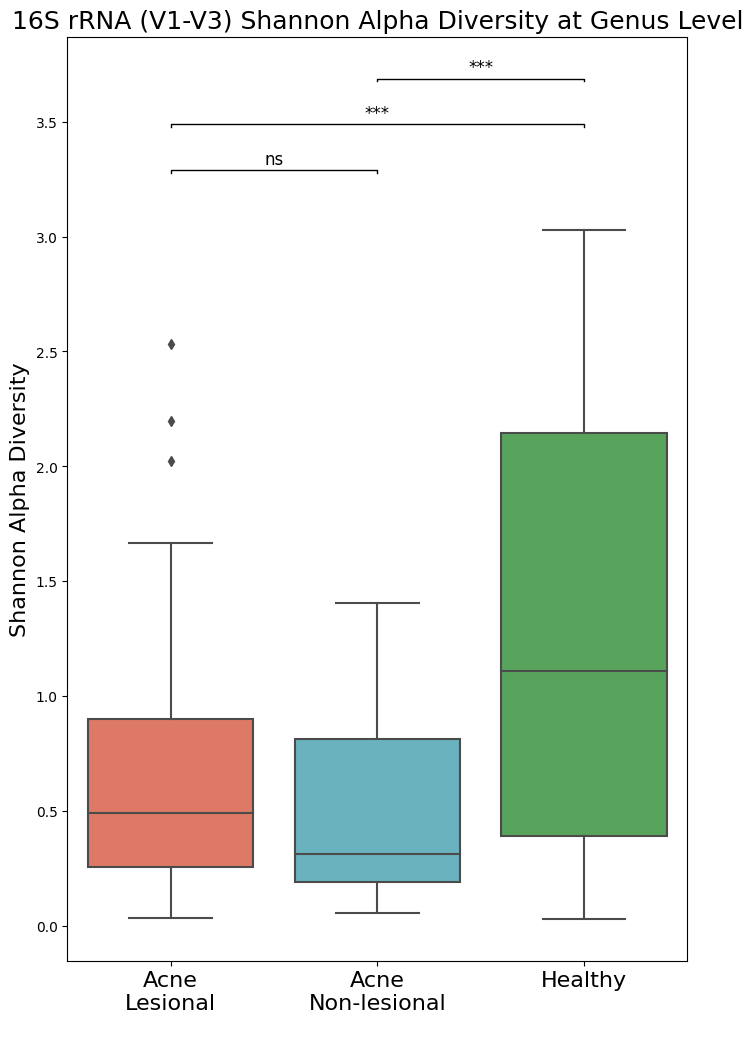

<Figure size 1000x600 with 0 Axes>

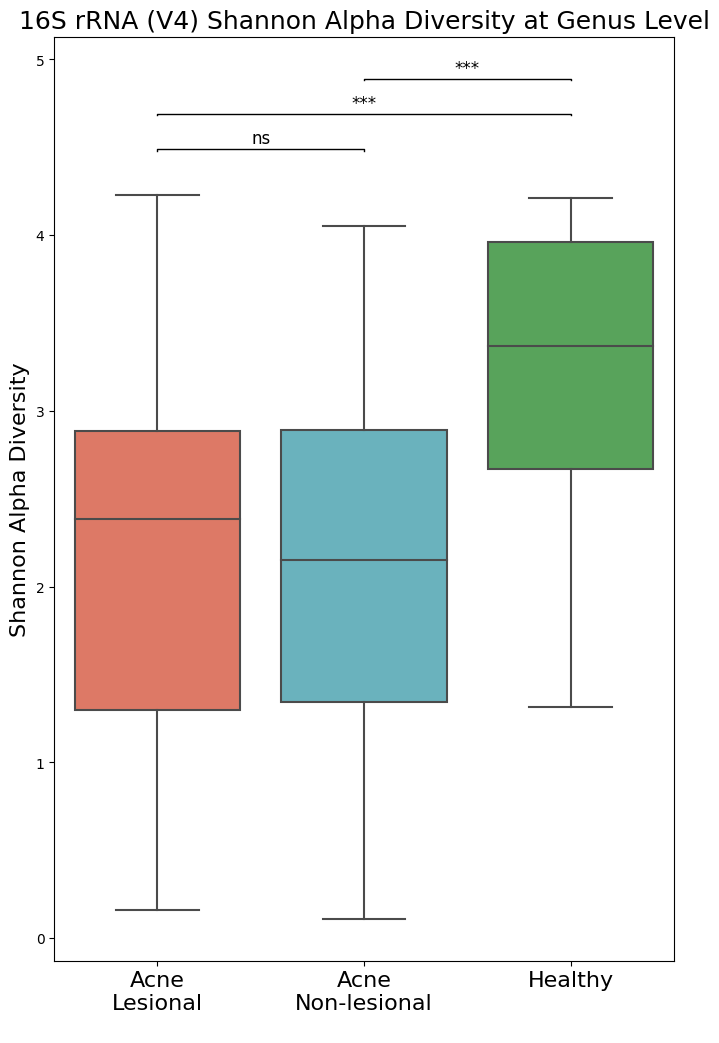

In [148]:
# Load metadata
metadata = pd.read_csv(metadata_path, sep='\t', index_col=0)

# Calculate and plot alpha diversity for both V1-V3 and V4 datasets
calculate_alpha_diversity_and_plot(biom_paths['V1-V3'], metadata, 'group', 'V1-V3')
calculate_alpha_diversity_and_plot(biom_paths['V4'], metadata, 'group', 'V4')